# Assignment Module 2: Pet Classification

The goal of this assignment is to implement a neural network that classifies images of 37 breeds of cats and dogs from the [Oxford-IIIT-Pet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). The assignment is divided into two parts: first, you will be asked to implement from scratch your own neural network for image classification; then, you will fine-tune a pretrained network provided by PyTorch.

### Import

In [6]:
!git clone https://github.com/CVLAB-Unibo/ipcv-assignment-2.git

fatal: destination path 'ipcv-assignment-2' already exists and is not an empty directory.


In [7]:
!pip install -q wandb
!pip install -q torchmetrics

In [8]:
from pathlib import Path
from PIL import Image
from torch import Tensor
from torch.utils.data import Dataset
from typing import Any, Callable, Dict, List, Optional, Tuple
import random
import time
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, AdamW
from torch.utils.data import random_split, DataLoader
from torchvision import transforms as T, datasets
import torchvision.transforms.v2 as v2
from torch.optim.lr_scheduler import OneCycleLR, ReduceLROnPlateau, CosineAnnealingLR
from torchmetrics.classification.accuracy import Accuracy
import copy
from torchvision.models import resnet18, ResNet18_Weights
import wandb

print("Using torch", torch.__version__)

Using torch 2.6.0+cu124


### Dataset

The following cells contain the code to download and access the dataset you will be using in this assignment. Note that, although this dataset features each and every image from [Oxford-IIIT-Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/), it uses a different train-val-test split than the original authors.

In [9]:
class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()

        self.root = Path("ipcv-assignment-2") / "dataset"
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

In [10]:
def get_datasets(train_transformer,test_transformer, batch_size):

    # --- Datasets ---
    train_dset = OxfordPetDataset(
        split="train",
        transform=train_transformer
    )
    val_dset = OxfordPetDataset(
        split="val",
        transform=test_transformer,
    )
    test_dset = OxfordPetDataset(
        split="test",
        transform=test_transformer,
    )

    # --- DataLoaders ---
    train_dl = DataLoader(
        train_dset,
        batch_size=batch_size,
        shuffle=True
    )
    val_dl = DataLoader(
        val_dset,
        batch_size=batch_size
    )
    test_dl = DataLoader(
        test_dset,
        batch_size=batch_size
    )

    return train_dl, val_dl, test_dl

### Fix randomness

In [12]:
def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(33)

### GPU check

In [13]:
gpu_avail = torch.cuda.is_available()
print(f"Is the GPU available? {gpu_avail}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device: {device}")

Is the GPU available? True
Device: cuda


### Free memory

In [14]:
import gc

torch.cuda.empty_cache()
gc.collect()

259

### Trainer class

In [15]:
class Trainer:
    def __init__(self,
                 model: nn.Module,
                 train_loader: DataLoader,
                 val_loader: DataLoader,
                 test_loader: DataLoader,
                 device: torch.device,
                 num_classes: int,
                 cfg: Dict[str, Any],
                 wandb_credentials: Optional[Tuple[str, str]] = None,
                 verbose: bool = False,
                 ) -> None:

        # Loaders
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader

        # Model to device
        self.device = device
        self.model = model.to(device)
        self.best_model = copy.deepcopy(self.model)
        self.best_state_dict = copy.deepcopy(self.model.state_dict())

        # Classes
        self.num_classes = num_classes

        # Epochs
        self.num_epochs = cfg["num_epochs"]

        # Optimizer
        self.optimizer = AdamW(self.model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])

        # Scheduler
        if cfg["scheduler"]:
          num_steps = self.num_epochs * len(train_loader)
          self.scheduler = OneCycleLR(self.optimizer, cfg["lr"], total_steps=num_steps)

        # Batch transformations (MixUp, CutMix, ...)
        self.batch_transforms = cfg["batch_transforms"]

        # Stats
        self.step = 0
        self.best_acc = 0.0
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []

        # Wandb credentials
        self.wandb_credentials = wandb_credentials
        if self.wandb_credentials is not None:
          WANDB_USER, WANDB_PROJECT = self.wandb_credentials
          wandb.init(name=cfg["run_name"], entity=WANDB_USER, project=WANDB_PROJECT, config=cfg)

        # Path for saving model
        self.ckpt_path = Path("ckpts")
        self.ckpt_path.mkdir(exist_ok=True)

        # Verbose
        self.verbose = verbose


    def logfn(self, values: Dict[str, Any]) -> None:
        wandb.log(values, step=self.step, commit=False)

    def train(self) -> None:
        for _ in tqdm(range(self.num_epochs), desc="Epoch"):
            self.model.train()

            for imgs, labels in self.train_loader:
                imgs = imgs.to(self.device)
                labels = labels.to(self.device)

                if self.batch_transforms:
                  imgs, labels = self.batch_transforms(imgs, labels)

                pred = self.model(imgs)
                loss = F.cross_entropy(pred, labels)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                self.scheduler.step()

                if self.wandb_credentials:
                    self.logfn({"train/loss": loss.item()})
                    self.logfn({"train/lr": self.scheduler.get_last_lr()[0]})

                self.step += 1

            if self.verbose:
              print(f"Epoch {_+1}")

            train_loss, train_accuracy = self.eval("train")
            val_loss, val_accuracy = self.eval("val")

            self.train_loss.append(train_loss)
            self.train_acc.append(train_accuracy)
            self.val_loss.append(val_loss)
            self.val_acc.append(val_accuracy)

        if self.wandb_credentials:
          wandb.finish()

    @torch.no_grad()
    def eval(self, split: str) -> Tuple[float, float]:
    
        if split == "test":
            self.best_model.load_state_dict(self.best_state_dict)
            model_to_eval = self.best_model

        else:
            model_to_eval = self.model
    
        model_to_eval.eval()
    
        loader = (
            self.train_loader if split == "train"
            else self.val_loader if split == "val"
            else self.test_loader
        )
    
        losses = []
        correct = 0
        total = 0
    
        for imgs, labels in loader:
            imgs = imgs.to(self.device)
            labels = labels.to(self.device)
    
            pred = model_to_eval(imgs)
            loss = F.cross_entropy(pred, labels)
            losses.append(loss.item())
    
            # accuracy al volo, senza softmax
            preds = pred.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
        loss = sum(losses) / len(losses)
        accuracy = correct / total
    
        if self.wandb_credentials:
            self.logfn({f"{split} loss": loss})
            self.logfn({f"{split} acc": accuracy})
        elif self.verbose:
            print(f"\t{split} loss {loss:.3f} - {split} accuracy {accuracy:.3f}")
    
        # if accuracy > self.best_acc and split == "val":
        #     self.best_acc = accuracy
        #     if self.wandb_credentials:
        #         torch.save(model_to_eval.state_dict(), self.ckpt_path / f"{wandb.run.name}.pth")
        #     else:
        #         torch.save(model_to_eval.state_dict(), self.ckpt_path / "best_model.pth")
    
        #     self.best_model = copy.deepcopy(model_to_eval)

        if accuracy > self.best_acc and split == "val":
            self.best_acc = accuracy

            self.best_state_dict = copy.deepcopy(model_to_eval.state_dict())
            if self.wandb_credentials:
                torch.save(self.best_state_dict, self.ckpt_path / f"{wandb.run.name}.pth")
            else:
                torch.save(self.best_state_dict, self.ckpt_path / "best_model.pth")
        
    
        return loss, accuracy


### Plot the history

In [16]:
def plot_history(history):

  fig, axes = plt.subplots(1, 2, figsize=(10,4))

  # Loss
  axes[0].plot(history["train_loss"], label="train")
  if history["val_loss"]:
      axes[0].plot(history["val_loss"], label="val")
  axes[0].set_title("Loss")
  axes[0].legend()

  # Accuracy
  axes[1].plot(history["train_acc"], label="train")
  if history["val_acc"]:
      axes[1].plot(history["val_acc"], label="val")
  axes[1].set_title("Accuracy")
  axes[1].legend()

  plt.tight_layout()
  plt.show()

## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `OxfordPetDataset`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~60%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~60% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

### CNN Architecture

In [17]:
# --- Residual Blocks ---

class BasicBlock(nn.Module): #basic convolutional block (conv+relu), neither batch normalization nor skip connections whatsoever

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.downsample = downsample

    def forward(self, x):

        out = self.conv1(x)
        out = torch.relu(out)
        out = self.conv2(out)
        out = torch.relu(out)
        
        return out

class BatchNormBlock(nn.Module): #basic convolutional block + batch normalization.

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):

        out = self.conv1(x)
        out = self.bn1(out)
        out = torch.relu(out)
        out = self.bn2(out)
        out = torch.relu(out)
        
        return out
    

class ResidualBlock(nn.Module): #residual block (BN + skip connections) but without bottleneck

    expansion = 1
    
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = torch.relu(out)
        return out



class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = torch.relu(self.bn1(self.conv1(x)))
        out = torch.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = torch.relu(out)
        return out


# --- General ResNet ---

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=37, input_channels=3, dropout=0.5):
        super(ResNet, self).__init__()
        self.in_channels = 64

        # Initial stem
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Adaptive pooling for variable input size
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x


### Model A (best)

Architecture:
- resnet [2,3,4,2]
- bottleneck blocks
- dropout

Training recipes:
- trivial augmentation
- long training
- lr scheduler (OneCycle)
- image resizing
- mixup
- cutmix
- AdamW optimizer

In [12]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

cfg_A = {
    # Pre-processing's parameters.
    "resize_size": 256,
    "crop_size": 224,

    # Training's parameters.
    "batch_size": 128,
    "num_epochs": 100,

    # Optimizer's parameters.
    "lr": 1e-3,
    "wd": 1e-4,
    "step_size": 5,

    # Batch transformations
    "batch_transforms" : v2.Compose([
        v2.MixUp(alpha=1.0, num_classes=n_classes),     # MIXUP
        v2.CutMix(alpha=1.0, num_classes=n_classes),    # CUTMIX
    ]),

    # Scheduler
    "scheduler":True,

    # Model
    'block_type': Bottleneck,
    'block_depths': [2, 3, 4, 2],
    'num_classes': n_classes,
    'input_channels': 3,
    'dropout': 0.5
}

# --- Transform for Data Augmentation and Img Resizing ---

train_transformer_A = T.Compose([
    T.RandomResizedCrop(cfg_A["crop_size"], scale=(0.8, 1.0)),     # RANDOM CROP RESIZE
    T.RandomHorizontalFlip(),                       # TRIVIAL AUGMENTATION
    T.ToTensor(),
    T.ConvertImageDtype(torch.float),
    T.RandomErasing(p=0.5,                          # RANDOM ERASING
                    scale=(0.02, 0.33),
                    ratio=(0.3, 3.3),
                    value=0,
                    inplace=False),
])

test_transformer_A = T.Compose([
    T.Resize(cfg_A["resize_size"]),                                  # RESIZE
    T.CenterCrop(cfg_A["crop_size"]),                              # CENTER CROP
    T.ToTensor(),
])

# --- DataLoaders ---

train_dl_A, val_dl_A, test_dl_A = get_datasets(train_transformer_A,
                                               test_transformer_A,
                                               cfg_A["batch_size"])

# --- Model ---

model_A = ResNet(cfg_A['block_type'],
             cfg_A['block_depths'],
             cfg_A['num_classes'],
             cfg_A['input_channels'],
             cfg_A['dropout'])

trainer_A = Trainer(
    model=model_A,
    train_loader=train_dl_A,
    val_loader=val_dl_A,
    test_loader=test_dl_A,
    device=device,
    num_classes=n_classes,
    cfg=cfg_A,
    verbose=True
)

trainer_A.train()


Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1
	train loss 3.668 - train accuracy 0.031
	val loss 3.665 - val accuracy 0.029
Epoch 2
	train loss 3.592 - train accuracy 0.044
	val loss 3.604 - val accuracy 0.038
Epoch 3
	train loss 3.650 - train accuracy 0.056
	val loss 3.599 - val accuracy 0.056
Epoch 4
	train loss 3.696 - train accuracy 0.061
	val loss 3.570 - val accuracy 0.066
Epoch 5
	train loss 3.573 - train accuracy 0.087
	val loss 3.485 - val accuracy 0.099
Epoch 6
	train loss 3.560 - train accuracy 0.092
	val loss 3.512 - val accuracy 0.086
Epoch 7
	train loss 3.419 - train accuracy 0.085
	val loss 3.395 - val accuracy 0.074
Epoch 8
	train loss 3.475 - train accuracy 0.100
	val loss 3.444 - val accuracy 0.070
Epoch 9
	train loss 3.306 - train accuracy 0.134
	val loss 3.337 - val accuracy 0.111
Epoch 10
	train loss 3.249 - train accuracy 0.129
	val loss 3.317 - val accuracy 0.117
Epoch 11
	train loss 3.484 - train accuracy 0.138
	val loss 3.353 - val accuracy 0.122
Epoch 12
	train loss 3.965 - train accuracy 0.128
	v

In [13]:
test_loss, test_accuracy = trainer_A.eval("test")

	test loss 1.504 - test accuracy 0.609


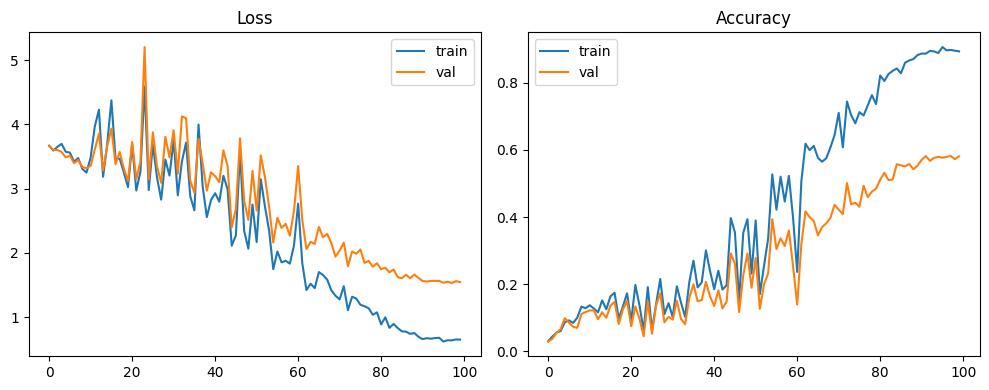

In [15]:
history_A = {
    "train_loss":trainer_A.train_loss,
    "train_acc":trainer_A.train_acc,
    "val_loss":trainer_A.val_loss,
    "val_acc":trainer_A.val_acc
}

plot_history(history_A)

### Model B

Architecture:
- resnet [2,3,4,2]
- normal residual blocks
- dropout

Same training recipes


In [18]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

cfg_B = {
    # Pre-processing's parameters.
    "resize_size": 256,
    "crop_size": 224,

    # Training's parameters.
    "batch_size": 128,
    "num_epochs": 100,

    # Optimizer's parameters.
    "lr": 1e-3,
    "wd": 1e-4,
    "step_size": 5,

    # Batch transformations
    "batch_transforms" : v2.Compose([
        v2.MixUp(alpha=1.0, num_classes=n_classes),     # MIXUP
        v2.CutMix(alpha=1.0, num_classes=n_classes),    # CUTMIX
    ]),

    # Scheduler
    "scheduler":True,

    # Model
    'block_type': ResidualBlock,
    'block_depths': [2, 3, 4, 2],
    'num_classes': n_classes,
    'input_channels': 3,
    'dropout': 0.5
}

# --- Transform for Data Augmentation and Img Resizing ---

train_transformer_B = T.Compose([
    T.RandomResizedCrop(cfg_B["crop_size"], scale=(0.8, 1.0)),     # RANDOM CROP RESIZE
    T.RandomHorizontalFlip(),                       # TRIVIAL AUGMENTATION
    T.ToTensor(),
    T.ConvertImageDtype(torch.float),
    T.RandomErasing(p=0.5,                          # RANDOM ERASING
                    scale=(0.02, 0.33),
                    ratio=(0.3, 3.3),
                    value=0,
                    inplace=False),
])

test_transformer_B = T.Compose([
    T.Resize(cfg_B["resize_size"]),                                  # RESIZE
    T.CenterCrop(cfg_B["crop_size"]),                              # CENTER CROP
    T.ToTensor(),
])

# --- DataLoaders ---

train_dl_B, val_dl_B, test_dl_B = get_datasets(train_transformer_B,
                                               test_transformer_B,
                                               cfg_B["batch_size"])



In [13]:
# --- Model ---

model_B = ResNet(cfg_B['block_type'],
             cfg_B['block_depths'],
             cfg_B['num_classes'],
             cfg_B['input_channels'],
             cfg_B['dropout'])

trainer_B = Trainer(
    model=model_B,
    train_loader=train_dl_B,
    val_loader=val_dl_B,
    test_loader=test_dl_B,
    device=device,
    num_classes=n_classes,
    cfg=cfg_B,
    verbose=True
)

trainer_B.train()
test_loss, test_accuracy = trainer_B.eval("test")

	test loss 1.455 - test accuracy 0.646


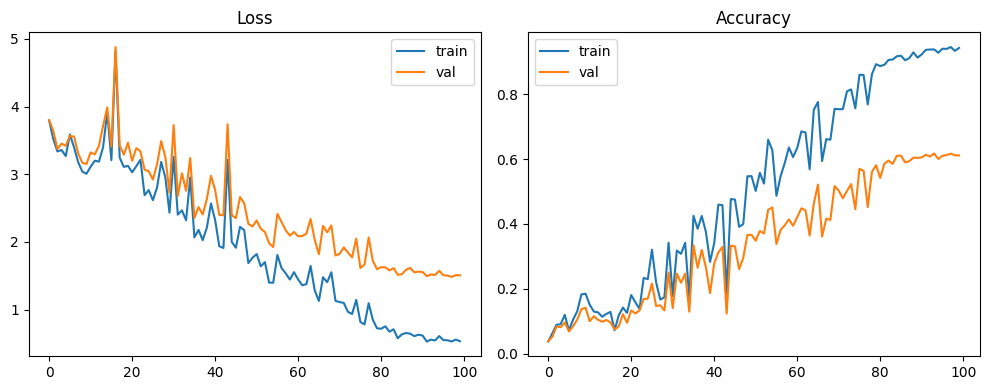

In [14]:
history_B = {
    "train_loss":trainer_B.train_loss,
    "train_acc":trainer_B.train_acc,
    "val_loss":trainer_B.val_loss,
    "val_acc":trainer_B.val_acc
}

plot_history(history_B)

###  

# ABLATION STUDIES

### Model C: a very shallow resnet

We want to show what happens when we use a very shallow ResNet, with residual blocks (no bottleneck). 

In [12]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

cfg_C = cfg_B
cfg_C['block_depths'] = [1,1,1,1]
train_dl_C = train_dl_B
val_dl_C = val_dl_B
test_dl_C = test_dl_B

model_C = ResNet(cfg_C['block_type'],
             cfg_C['block_depths'],
             cfg_C['num_classes'],
             cfg_C['input_channels'],
             cfg_C['dropout'])

trainer_C = Trainer(
    model=model_C,
    train_loader=train_dl_C,
    val_loader=val_dl_C,
    test_loader=test_dl_C,
    device=device,
    num_classes=n_classes,
    cfg=cfg_C,
    verbose=True
)

trainer_C.train()

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1
	train loss 3.671 - train accuracy 0.031
	val loss 3.697 - val accuracy 0.030
Epoch 2
	train loss 3.422 - train accuracy 0.086
	val loss 3.488 - val accuracy 0.067
Epoch 3
	train loss 3.339 - train accuracy 0.108
	val loss 3.390 - val accuracy 0.095
Epoch 4
	train loss 3.262 - train accuracy 0.131
	val loss 3.331 - val accuracy 0.100
Epoch 5
	train loss 3.218 - train accuracy 0.134
	val loss 3.307 - val accuracy 0.111
Epoch 6
	train loss 3.187 - train accuracy 0.128
	val loss 3.270 - val accuracy 0.107
Epoch 7
	train loss 3.251 - train accuracy 0.111
	val loss 3.302 - val accuracy 0.086
Epoch 8
	train loss 3.112 - train accuracy 0.149
	val loss 3.229 - val accuracy 0.113
Epoch 9
	train loss 3.137 - train accuracy 0.163
	val loss 3.230 - val accuracy 0.114
Epoch 10
	train loss 3.139 - train accuracy 0.144
	val loss 3.306 - val accuracy 0.098
Epoch 11
	train loss 3.488 - train accuracy 0.105
	val loss 3.623 - val accuracy 0.092
Epoch 12
	train loss 3.369 - train accuracy 0.104
	v

In [14]:
test_loss, test_accuracy = trainer_C.eval("test")

	test loss 1.535 - test accuracy 0.607


Despite halving the depth of the network, the performance of this shallow ResNet did not drop excessively.

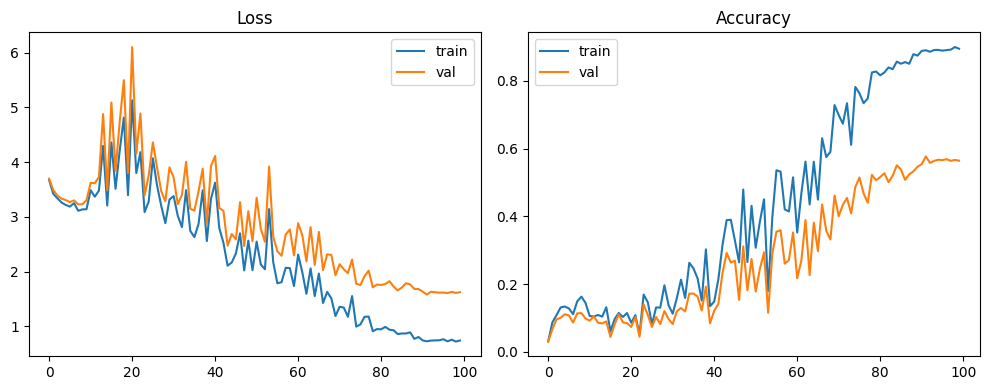

In [15]:
history_C = {
    "train_loss":trainer_C.train_loss,
    "train_acc":trainer_C.train_acc,
    "val_loss":trainer_C.val_loss,
    "val_acc":trainer_C.val_acc
}

plot_history(history_C)

### Model D, E and F: best network obtained (resnset20 with residual blocks) but with 3 different blocks: basic, batchnorm, bottleneck

In [19]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

#we copy the configuration and dataloaders of our 'ultimate' model, modifying the block_type field
cfg_D = cfg_E = cfg_F = cfg_B

cfg_D['block_type'] = BasicBlock
cfg_E['block_type'] = BatchNormBlock
cfg_F['block_type'] = Bottleneck

# --- DataLoaders ---
train_dl_D = train_dl_E = train_dl_F = train_dl_B
val_dl_D = val_dl_E = val_dl_F = val_dl_B
test_dl_D = test_dl_E = test_dl_F = test_dl_B

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1
	train loss 3.668 - train accuracy 0.031
	val loss 3.665 - val accuracy 0.029
Epoch 2
	train loss 3.592 - train accuracy 0.044
	val loss 3.604 - val accuracy 0.038
Epoch 3
	train loss 3.650 - train accuracy 0.056
	val loss 3.599 - val accuracy 0.056
Epoch 4
	train loss 3.696 - train accuracy 0.061
	val loss 3.570 - val accuracy 0.066
Epoch 5
	train loss 3.573 - train accuracy 0.087
	val loss 3.485 - val accuracy 0.099
Epoch 6
	train loss 3.560 - train accuracy 0.092
	val loss 3.512 - val accuracy 0.086
Epoch 7
	train loss 3.419 - train accuracy 0.085
	val loss 3.395 - val accuracy 0.074
Epoch 8
	train loss 3.475 - train accuracy 0.100
	val loss 3.444 - val accuracy 0.070
Epoch 9
	train loss 3.306 - train accuracy 0.134
	val loss 3.337 - val accuracy 0.111
Epoch 10
	train loss 3.249 - train accuracy 0.129
	val loss 3.317 - val accuracy 0.117
Epoch 11
	train loss 3.484 - train accuracy 0.138
	val loss 3.353 - val accuracy 0.122
Epoch 12
	train loss 3.965 - train accuracy 0.128
	v

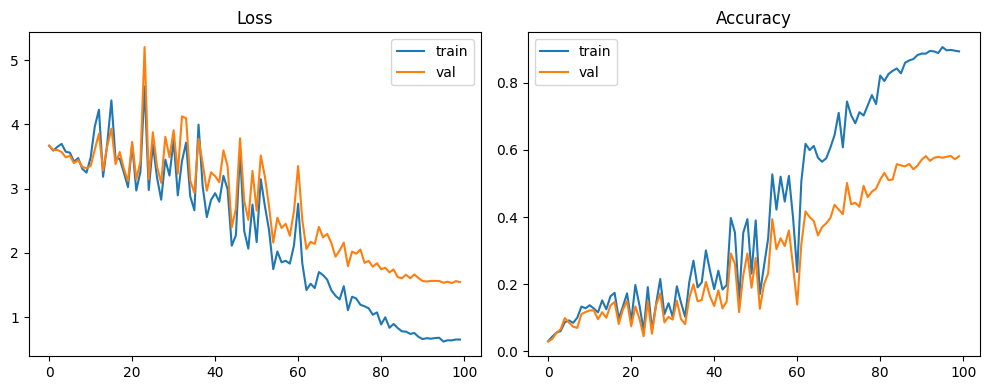

In [20]:
#MODEL D: BasicBlock without BatchNormalization and SkipConnections 
# --- Model ---

model_D = ResNet(cfg_D['block_type'],
             cfg_D['block_depths'],
             cfg_D['num_classes'],
             cfg_D['input_channels'],
             cfg_D['dropout'])

trainer_D = Trainer(
    model=model_D,
    train_loader=train_dl_D,
    val_loader=val_dl_D,
    test_loader=test_dl_D,
    device=device,
    num_classes=n_classes,
    cfg=cfg_D,
    verbose=True
)

trainer_D.train()

test_loss, test_accuracy = trainer_D.eval("test")

history_D = {
    "train_loss":trainer_D.train_loss,
    "train_acc":trainer_D.train_acc,
    "val_loss":trainer_D.val_loss,
    "val_acc":trainer_D.val_acc
}

plot_history(history_D)

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1
	train loss 3.705 - train accuracy 0.028
	val loss 3.711 - val accuracy 0.028
Epoch 2
	train loss 3.570 - train accuracy 0.042
	val loss 3.598 - val accuracy 0.042
Epoch 3
	train loss 4.189 - train accuracy 0.044
	val loss 3.836 - val accuracy 0.059
Epoch 4
	train loss 3.987 - train accuracy 0.053
	val loss 3.723 - val accuracy 0.069
Epoch 5
	train loss 3.685 - train accuracy 0.063
	val loss 3.609 - val accuracy 0.070
Epoch 6
	train loss 3.500 - train accuracy 0.072
	val loss 3.553 - val accuracy 0.081
Epoch 7
	train loss 3.475 - train accuracy 0.088
	val loss 3.443 - val accuracy 0.083
Epoch 8
	train loss 3.353 - train accuracy 0.108
	val loss 3.384 - val accuracy 0.097
Epoch 9
	train loss 3.387 - train accuracy 0.105
	val loss 3.448 - val accuracy 0.075
Epoch 10
	train loss 3.420 - train accuracy 0.109
	val loss 3.440 - val accuracy 0.092
Epoch 11
	train loss 3.298 - train accuracy 0.114
	val loss 3.362 - val accuracy 0.108
Epoch 12
	train loss 3.428 - train accuracy 0.107
	v

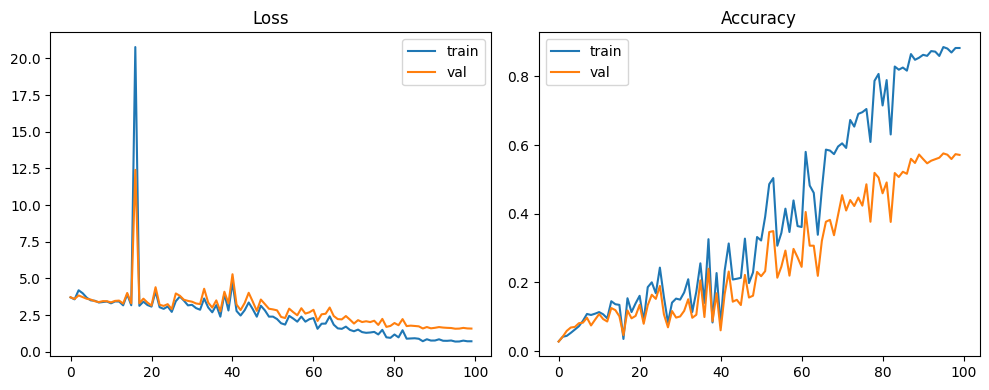

In [21]:
#MODEL E: BasicBlock with BN
# --- Model ---

model_E = ResNet(cfg_E['block_type'],
             cfg_E['block_depths'],
             cfg_E['num_classes'],
             cfg_E['input_channels'],
             cfg_E['dropout'])

trainer_E = Trainer(
    model=model_E,
    train_loader=train_dl_E,
    val_loader=val_dl_E,
    test_loader=test_dl_E,
    device=device,
    num_classes=n_classes,
    cfg=cfg_E,
    verbose=True
)

trainer_E.train()

test_loss, test_accuracy = trainer_E.eval("test")

history_E = {
    "train_loss":trainer_E.train_loss,
    "train_acc":trainer_E.train_acc,
    "val_loss":trainer_E.val_loss,
    "val_acc":trainer_E.val_acc
}

plot_history(history_E)

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1
	train loss 3.685 - train accuracy 0.027
	val loss 3.685 - val accuracy 0.027
Epoch 2
	train loss 3.549 - train accuracy 0.052
	val loss 3.573 - val accuracy 0.062
Epoch 3
	train loss 3.904 - train accuracy 0.041
	val loss 3.731 - val accuracy 0.059
Epoch 4
	train loss 3.473 - train accuracy 0.081
	val loss 3.454 - val accuracy 0.085
Epoch 5
	train loss 3.497 - train accuracy 0.072
	val loss 3.458 - val accuracy 0.059
Epoch 6
	train loss 3.337 - train accuracy 0.107
	val loss 3.372 - val accuracy 0.079
Epoch 7
	train loss 3.428 - train accuracy 0.102
	val loss 3.446 - val accuracy 0.085
Epoch 8
	train loss 3.290 - train accuracy 0.102
	val loss 3.380 - val accuracy 0.084
Epoch 9
	train loss 3.269 - train accuracy 0.126
	val loss 3.338 - val accuracy 0.092
Epoch 10
	train loss 3.164 - train accuracy 0.144
	val loss 3.289 - val accuracy 0.112
Epoch 11
	train loss 3.555 - train accuracy 0.123
	val loss 3.551 - val accuracy 0.088
Epoch 12
	train loss 3.193 - train accuracy 0.134
	v

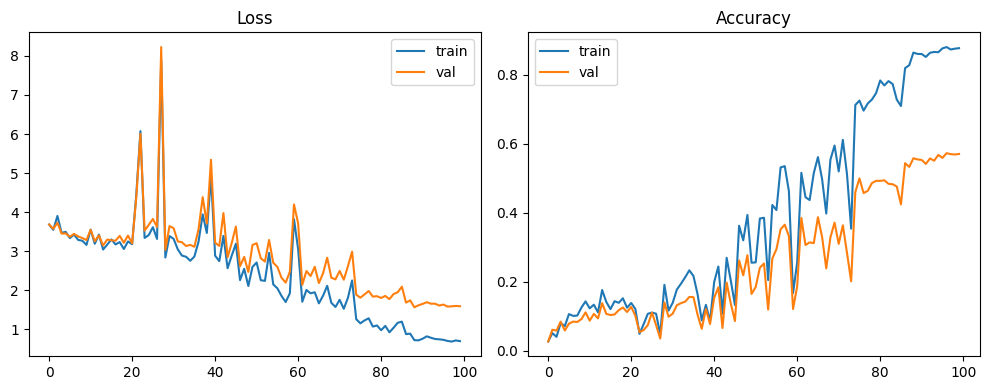

In [22]:
#MODEL F: Bottleneck 
# --- Model ---

model_F = ResNet(cfg_F['block_type'],
             cfg_F['block_depths'],
             cfg_F['num_classes'],
             cfg_F['input_channels'],
             cfg_F['dropout'])

trainer_F = Trainer(
    model=model_F,
    train_loader=train_dl_F,
    val_loader=val_dl_F,
    test_loader=test_dl_F,
    device=device,
    num_classes=n_classes,
    cfg=cfg_F,
    verbose=True
)

trainer_F.train()

test_loss, test_accuracy = trainer_F.eval("test")

history_F = {
    "train_loss":trainer_F.train_loss,
    "train_acc":trainer_F.train_acc,
    "val_loss":trainer_F.val_loss,
    "val_acc":trainer_F.val_acc
}

plot_history(history_F)

### Ablation on the training recipes

We now try to remove some of the training recipes we employed in our best netork.

In [23]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---
cfg_G = cfg_B
cfg_G['batch_transforms'] = None
#we remove most of the data augmentation techniques
train_transformer_G = T.Compose([
    T.RandomResizedCrop(cfg_G["crop_size"], scale=(0.8, 1.0)),     # RANDOM CROP RESIZE
    T.ToTensor(),
])

test_transformer_G = T.Compose([
    T.Resize(cfg_G["resize_size"]),                                  # RESIZE
    T.CenterCrop(cfg_G["crop_size"]),                              # CENTER CROP
    T.ToTensor(),
])

# --- DataLoaders ---

train_dl_G, val_dl_G, test_dl_G = get_datasets(train_transformer_G,
                                               test_transformer_G,
                                               cfg_G["batch_size"])

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1
	train loss 3.838 - train accuracy 0.027
	val loss 3.848 - val accuracy 0.027
Epoch 2
	train loss 3.542 - train accuracy 0.063
	val loss 3.616 - val accuracy 0.050
Epoch 3
	train loss 3.234 - train accuracy 0.119
	val loss 3.391 - val accuracy 0.088
Epoch 4
	train loss 3.119 - train accuracy 0.143
	val loss 3.356 - val accuracy 0.098
Epoch 5
	train loss 2.971 - train accuracy 0.185
	val loss 3.251 - val accuracy 0.112
Epoch 6
	train loss 2.825 - train accuracy 0.197
	val loss 3.242 - val accuracy 0.123
Epoch 7
	train loss 3.116 - train accuracy 0.161
	val loss 3.623 - val accuracy 0.091
Epoch 8
	train loss 2.823 - train accuracy 0.230
	val loss 3.398 - val accuracy 0.140
Epoch 9
	train loss 3.109 - train accuracy 0.198
	val loss 3.715 - val accuracy 0.113
Epoch 10
	train loss 2.637 - train accuracy 0.283
	val loss 3.444 - val accuracy 0.186
Epoch 11
	train loss 5.424 - train accuracy 0.140
	val loss 5.722 - val accuracy 0.106
Epoch 12
	train loss 3.960 - train accuracy 0.181
	v

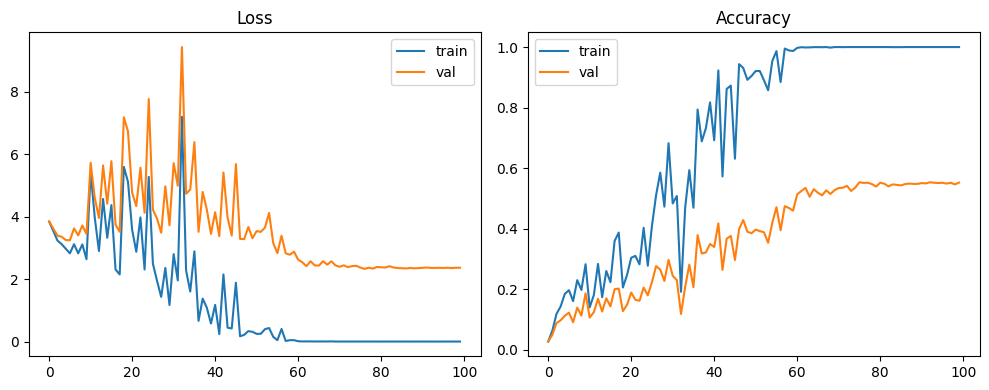

In [24]:
# --- Model ---

model_G = ResNet(cfg_G['block_type'],
             cfg_G['block_depths'],
             cfg_G['num_classes'],
             cfg_G['input_channels'],
             cfg_G['dropout'])

trainer_G = Trainer(
    model=model_G,
    train_loader=train_dl_G,
    val_loader=val_dl_G,
    test_loader=test_dl_G,
    device=device,
    num_classes=n_classes,
    cfg=cfg_G,
    verbose=True
)

trainer_G.train()

test_loss, test_accuracy = trainer_G.eval("test")

history_G = {
    "train_loss":trainer_G.train_loss,
    "train_acc":trainer_G.train_acc,
    "val_loss":trainer_G.val_loss,
    "val_acc":trainer_G.val_acc
}

plot_history(history_G)

### No Dropout

In [ ]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

#we copy the configuration and dataloaders of our 'ultimate' model, modifying the block_type field
cfg_H = cfg_B

cfg_H['dropout'] = 0

# --- DataLoaders ---
train_dl_H = train_dl_B
val_dl_H = val_dl_B
test_dl_H = test_dl_B

#MODEL H: our best model but without dropout
# --- Model ---

model_H = ResNet(cfg_H['block_type'],
             cfg_H['block_depths'],
             cfg_H['num_classes'],
             cfg_H['input_channels'],
             cfg_H['dropout'])

trainer_H = Trainer(
    model=model_H,
    train_loader=train_dl_H,
    val_loader=val_dl_H,
    test_loader=test_dl_H,
    device=device,
    num_classes=n_classes,
    cfg=cfg_H,
    verbose=True
)

trainer_H.train()

test_loss, test_accuracy = trainer_H.eval("test")

history_H = {
    "train_loss":trainer_H.train_loss,
    "train_acc":trainer_H.train_acc,
    "val_loss":trainer_H.val_loss,
    "val_acc":trainer_H.val_acc
}

plot_history(history_H)

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `OxfordPetDataset`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters in order to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~90%.

In [17]:
def get_model(
        num_classes: int,
        weights: Optional[ResNet18_Weights] = None
    ) -> nn.Module:
    """Gets an image classifier based on ResNet-18.

    Args:
        num_classes: the number of classes.
        weights: pretrained weights to load into the network.
                 If None, the network is randomly initialized.

    Returns:
        The required network.
    """
    model = resnet18(weights=weights)
    # Here we override the old classifier
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

def set_requires_grad(layer: torch.nn.Module, train: bool) -> None:
    """Sets the requires_grad attribute to True or False for each parameter within a layer.

        Args:
            layer: the layer to freeze.
            train: if true train the layer.
    """
    for p in layer.parameters():
        p.requires_grad = train

In [32]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

cfg_2A = {
    # Pre-processing's parameters.
    "resize_size": 256,
    "crop_size": 224,

    # Training's parameters.
    "batch_size": 128,
    "num_epochs": 10,

    # Optimizer's parameters.
    "lr": 1e-3,
    "wd": 1e-4,
    "step_size": 5,

    # Batch transformations
    "batch_transforms" : v2.Compose([
        v2.MixUp(alpha=1.0, num_classes=n_classes),     # MIXUP
        v2.CutMix(alpha=1.0, num_classes=n_classes),    # CUTMIX
    ]),

    # Scheduler
    "scheduler":True,
}

# --- Transform for Data Augmentation and Img Resizing ---

train_transformer_2A = T.Compose([
    T.RandomResizedCrop(cfg_2A["crop_size"], scale=(0.8, 1.0)),     # RANDOM CROP RESIZE
    T.RandomHorizontalFlip(),                       # TRIVIAL AUGMENTATION
    T.ToTensor(),
    T.ConvertImageDtype(torch.float),
    T.RandomErasing(p=0.5,                          # RANDOM ERASING
                    scale=(0.02, 0.33),
                    ratio=(0.3, 3.3),
                    value=0,
                    inplace=False),
])

test_transformer_2A = T.Compose([
    T.Resize(cfg_2A["resize_size"]),                                  # RESIZE
    T.CenterCrop(cfg_2A["crop_size"]),                              # CENTER CROP
    T.ToTensor(),
])

# --- DataLoaders ---

train_dl_2A, val_dl_2A, test_dl_2A = get_datasets(train_transformer_2A,
                                               test_transformer_2A,
                                               cfg_2A["batch_size"])

# --- Model ---

weights = ResNet18_Weights.IMAGENET1K_V1
model_2A = get_model(n_classes, weights).to(device)

set_requires_grad(model_2A.conv1, False)
set_requires_grad(model_2A.bn1, False)
set_requires_grad(model_2A.layer1, False)
set_requires_grad(model_2A.layer2, False)
set_requires_grad(model_2A.layer3, False)
set_requires_grad(model_2A.layer4, False)


In [33]:
trainer = Trainer(
    model=model_2A,
    train_loader=train_dl_2A,
    val_loader=val_dl_2A,
    test_loader=test_dl_2A,
    device=device,
    num_classes=n_classes,
    cfg=cfg_2A
)

trainer.train()

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

train loss 3.557 - train accuracy 0.064
val loss 3.515 - val accuracy 0.067
train loss 3.015 - train accuracy 0.289
val loss 2.934 - val accuracy 0.285
train loss 2.292 - train accuracy 0.569
val loss 2.185 - val accuracy 0.605
train loss 1.877 - train accuracy 0.667
val loss 1.754 - val accuracy 0.682
train loss 1.614 - train accuracy 0.729
val loss 1.498 - val accuracy 0.757
train loss 1.497 - train accuracy 0.744
val loss 1.392 - val accuracy 0.774
train loss 1.392 - train accuracy 0.754
val loss 1.294 - val accuracy 0.776
train loss 1.355 - train accuracy 0.785
val loss 1.261 - val accuracy 0.804
train loss 1.358 - train accuracy 0.779
val loss 1.243 - val accuracy 0.806
train loss 1.336 - train accuracy 0.784
val loss 1.242 - val accuracy 0.805


In [34]:
trainer.eval("test")

test loss 1.212 - test accuracy 0.827
